In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mimg
%matplotlib inline
#plt.rcParams["figure.figsize"] = (20,10)
from PIL import Image
from scipy import misc

import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from keras.models import Sequential, load_model
from keras.layers import Dense, Activation, Dropout
from keras.callbacks import ModelCheckpoint, EarlyStopping

from keras.preprocessing import sequence
#from keras.layers import Embedding
from keras.models import Sequential, load_model
#from keras.layers import Convolution1D, Dense, Activation, Dropout, Flatten, MaxPooling1D, Lambda
from keras.utils import np_utils
#from keras import backend as K
from keras.utils.np_utils import to_categorical

import h5py
from keras import callbacks
from keras.layers import SimpleRNN
from keras.layers import GRU
from keras.callbacks import CSVLogger
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

Using TensorFlow backend.


In [2]:
dataset = pd.read_csv('H:/best features/binary/combined_bestfeatures_binary.csv', low_memory=False)

X = dataset.iloc[:,0:23]
y = dataset.iloc[:,23]

In [3]:
#X = np.expand_dims(X, axis=2)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
train_ratio = 0.60
validation_ratio = 0.20
test_ratio = 0.20

# train is now 75% of the entire data set
# the _junk suffix means that we drop that variable completely
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_ratio, random_state = 42)

# test is now 10% of the initial data set
# validation is now 15% of the initial data set
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio), random_state = 42) 

print(X_train, 
      X_val, 
      X_test)

              FLD      TLFP      FPLM     BPLMI    BPLSTD   FLIATME  FLIATSTD  \
525966   0.000495  0.000003  0.009497  0.062865  0.000000  0.000495  0.000000   
610481   0.006080  0.000011  0.008339  0.085548  0.000000  0.001216  0.003651   
560136   0.000001  0.000000  0.000000  0.000000  0.000000  0.000001  0.000000   
608108   0.000000  0.000000  0.001390  0.003889  0.000000  0.000000  0.000000   
196727   0.000001  0.000251  0.005948  0.015753  0.000000  0.000000  0.000001   
...           ...       ...       ...       ...       ...       ...       ...   
259178   0.000445  0.000207  0.014064  0.113014  0.000000  0.000544  0.000000   
1414414  0.829818  0.000303  0.011421  0.000000  0.609846  0.082982  0.371462   
131932   0.004216  0.000142  0.002241  0.000000  0.269363  0.000675  0.002615   
671155   0.000002  0.000009  0.012740  0.056384  0.000000  0.000001  0.000001   
121958   0.745638  0.000306  0.001810  0.000000  0.214504  0.064325  0.349711   

          FLIATMI    FIATME

In [4]:
print(y_train, y_val, y_test)

525966     0
610481     0
560136     0
608108     0
196727     0
          ..
259178     0
1414414    1
131932     1
671155     0
121958     1
Name: CLASS, Length: 1101341, dtype: int64 1456897    1
422466     0
211246     0
207983     0
1040251    0
          ..
735006     0
1079951    0
1203070    0
580722     0
1260593    0
Name: CLASS, Length: 367114, dtype: int64 767929     0
11647      0
464665     0
600761     0
277873     0
          ..
1552678    0
1264806    0
1752882    0
568447     0
300036     0
Name: CLASS, Length: 367114, dtype: int64


In [5]:
X_train = np.expand_dims(X_train, axis=2)
X_val = np.expand_dims(X_val, axis=2)
X_test = np.expand_dims(X_test, axis=2)

In [6]:
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))

In [7]:
model = Sequential()
model.add(GRU(128,input_shape=(None, 23), return_sequences=True))  
model.add(Dropout(0.1))
model.add(GRU(128,return_sequences=True)) 
model.add(Dropout(0.1))
model.add(GRU(128, return_sequences=True))  
model.add(Dropout(0.1))
model.add(GRU(128, return_sequences=False)) 
model.add(Dropout(0.1))
model.add(Dense(1))
model.add(Activation('sigmoid'))

In [8]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
gru_1 (GRU)                  (None, None, 128)         58368     
_________________________________________________________________
dropout_1 (Dropout)          (None, None, 128)         0         
_________________________________________________________________
gru_2 (GRU)                  (None, None, 128)         98688     
_________________________________________________________________
dropout_2 (Dropout)          (None, None, 128)         0         
_________________________________________________________________
gru_3 (GRU)                  (None, None, 128)         98688     
_________________________________________________________________
dropout_3 (Dropout)          (None, None, 128)         0         
_________________________________________________________________
gru_4 (GRU)                  (None, 128)              

In [9]:
model.compile(loss="binary_crossentropy", optimizer="adam",metrics=['accuracy'])

In [12]:
checkpointer = callbacks.ModelCheckpoint(filepath="H:/best features/results/binary results/checkpoint-{epoch:02d}.hdf5", verbose=1, save_best_only=True, monitor='val_acc',mode='max')
csv_logger = CSVLogger('H:/best features/results/binary results/bgrutrainanalysis.csv',separator=',', append=False)
model.fit(X_train, y_train, batch_size = 1000, epochs=28, validation_data=(X_val, y_val),callbacks=[checkpointer,csv_logger])
#cnn.fit(X_train, y_train, nb_epoch=1000, show_accuracy=True,validation_data=(X_test, y_test),callbacks=[checkpointer,csv_logger])
model.save("H:/best features/results/binary results/bgru_model.hdf5")

Train on 1101341 samples, validate on 367114 samples
Epoch 1/28
1101341/1101341 [==============================] - 124s 112us/step - loss: 0.0337 - accuracy: 0.9881 - val_loss: 0.0301 - val_accuracy: 0.9891
Epoch 2/28
1101341/1101341 [==============================] - 91s 83us/step - loss: 0.0324 - accuracy: 0.9884 - val_loss: 0.0309 - val_accuracy: 0.9885
Epoch 3/28
1101341/1101341 [==============================] - 92s 83us/step - loss: 0.0311 - accuracy: 0.9889 - val_loss: 0.0282 - val_accuracy: 0.9896
Epoch 4/28
1101341/1101341 [==============================] - 92s 84us/step - loss: 0.0301 - accuracy: 0.9892 - val_loss: 0.0266 - val_accuracy: 0.9900
Epoch 5/28
1101341/1101341 [==============================] - 92s 84us/step - loss: 0.0291 - accuracy: 0.9895 - val_loss: 0.0261 - val_accuracy: 0.9901
Epoch 6/28
1101341/1101341 [==============================] - 92s 84us/step - loss: 0.0281 - accuracy: 0.9897 - val_loss: 0.0271 - val_accuracy: 0.9896
Epoch 7/28
1101341/1101341 [=====

In [13]:
score = model.evaluate(X_test, y_test)
print('For Test')
print('Loss: %.4f' % score[0])
print('Accuracy: %.2f' % (score[1]*100))

367114/367114 [==============================] - 20s 55us/step
For Test
Loss: 0.0174
Accuracy: 99.35


In [14]:
pred1 = model.predict(X_test)
# predict classes for test set
prediction_y_classes = model.predict_classes(X_test)

In [15]:
pred1[:12]

array([[9.4151376e-03],
       [1.5146973e-07],
       [2.1588028e-05],
       [1.3466913e-03],
       [1.6517289e-07],
       [2.0394690e-07],
       [2.4924371e-03],
       [2.5040649e-07],
       [9.9999976e-01],
       [1.0502355e-05],
       [2.4719251e-05],
       [9.9999964e-01]], dtype=float32)

In [16]:
prediction_y_classes[:12]

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1]])

In [17]:
y_test[:12]

767929     0
11647      0
464665     0
600761     0
277873     0
264155     0
723875     0
623995     0
1373499    1
248381     0
838570     0
1400622    1
Name: CLASS, dtype: int64

In [18]:
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test, prediction_y_classes)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(y_test, prediction_y_classes)
print('Precision: %f' % precision)
# recall: tp / (tp + fn)
recall = recall_score(y_test, prediction_y_classes)
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test, prediction_y_classes)
print('F1 score: %f' % f1)

Accuracy: 0.993536
Precision: 0.985410
Recall: 0.979176
F1 score: 0.982283


In [19]:
conf = confusion_matrix(y_test.astype(int), prediction_y_classes.astype(int))

In [20]:
conf

array([[298958,    974],
       [  1399,  65783]], dtype=int64)

In [21]:
print(classification_report(y_test.astype(int), prediction_y_classes.astype(int)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    299932
           1       0.99      0.98      0.98     67182

    accuracy                           0.99    367114
   macro avg       0.99      0.99      0.99    367114
weighted avg       0.99      0.99      0.99    367114



In [22]:
#function to draw confusion matrix
def draw_confusion_matrix(true,preds):
    conf_matx = confusion_matrix(true, preds)
    sns.heatmap(conf_matx, annot=True,annot_kws={"size": 20},fmt='g', cbar=False, cmap="viridis")
    plt.show()
    #return conf_matx

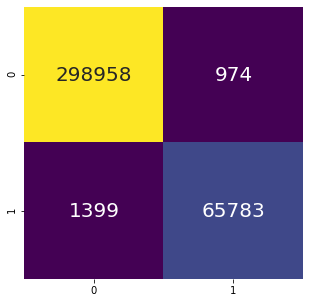

In [23]:
plt.rcParams["figure.figsize"] = (5,5)
draw_confusion_matrix(y_test.astype(int), prediction_y_classes.astype(int))

In [24]:
#t1=sum(x==0 for x in pred1-y_test)/len(pred1)

from scipy import interp
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn.metrics import roc_curve, auc

fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, pred1)
auc_keras = auc(fpr_keras, tpr_keras)

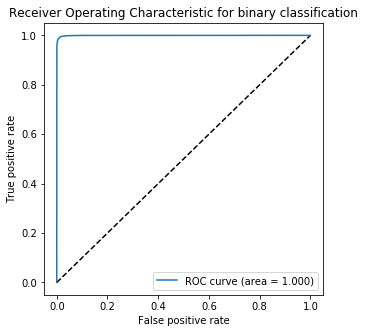

In [25]:
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label='ROC curve (area = {:.3f})'.format(auc_keras))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Receiver Operating Characteristic for binary classification')
plt.legend(loc='best')
plt.show()

In [26]:
from sklearn.metrics import average_precision_score
average_precision = average_precision_score(y_test, pred1)

print('Average precision-recall score: {0:0.2f}'.format(average_precision))

Average precision-recall score: 1.00
